In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [99]:
# -----------------------------
# 0) NATO ISO-2 country codes
# -----------------------------
NATO_ISO2 = {
    "AL","BE","BG","HR","CZ","DK","EE","FI","FR","DE","GR","HU","IS","IT",
    "LV","LT","LU","ME","NL","MK","NO","PL","PT","RO","SK","SI","ES","SE",
    "TR","GB","CA","US"
}

# -----------------------------
# 1) Load raw CSVs
# -----------------------------
airports_raw = pd.read_csv("data/airports.csv")
routes_raw   = pd.read_csv("data/routes.csv")


In [100]:
# -----------------------------
# 2) Flexible column detection (airports)
# -----------------------------
acols = {c.lower(): c for c in airports_raw.columns}
def pick(*cands):
    for c in cands:
        if c in acols:
            return acols[c]
    return None

col_ident     = pick("ident","icao","gps_code","icao_code")
col_iata      = pick("iata_code","iata")
col_country   = pick("iso_country","country_iso","country")
col_type      = pick("type")
col_name      = pick("name")
col_continent = pick("continent")

use_cols = [c for c in [col_name, col_type, col_country, col_iata, col_ident, col_continent] if c is not None]
airports = airports_raw[use_cols].copy()

std_cols = ["name","atype","country","iata","icao","continent"]
airports.columns = std_cols[:len(use_cols)]
for need in std_cols:
    if need not in airports.columns:
        airports[need] = np.nan

In [101]:
# -----------------------------
# 3) Clean strings + fill US continent + post-fill dropna
# -----------------------------
for c in ["iata","icao","country","continent"]:
    airports[c] = airports[c].astype(str).str.upper().str.strip()

# Fill continent = "NA" where country == "US" and continent missing/blank
mask_us_missing = (airports["country"] == "US") & (
    airports["continent"].isna() | (airports["continent"] == "") | (airports["continent"] == "NAN")
)
airports.loc[mask_us_missing, "continent"] = "NA"

# NOW drop remaining critical missings (post-fill)
airports.replace({"NAN": np.nan, "": np.nan}, inplace=True)
airports = airports.dropna(subset=["country", "continent"])  # keep airports with continent known
# (We’ll derive a canonical 'node' next and dropna again after that.)

In [102]:
# 4) Filter to NATO + build canonical node + alias
# -----------------------------
airports = airports[airports["country"].isin(NATO_ISO2)].copy()

# Canonical node: prefer IATA else ICAO
has_iata = airports["iata"].notna()
airports["node"] = np.where(has_iata & (airports["iata"].str.len() > 0), airports["iata"], airports["icao"])

# Drop if we still don't have a usable node
airports = airports.replace({"": np.nan})
airports = airports.dropna(subset=["node"])

# De-duplicate nodes (pick best airport type if duplicates)
size_rank = {"LARGE_AIRPORT": 0, "MEDIUM_AIRPORT": 1, "SMALL_AIRPORT": 2}
airports["_atype_rank"] = airports["atype"].str.upper().map(size_rank).fillna(3)
airports_u = (airports.sort_values(["node", "_atype_rank"])
                      .drop_duplicates(subset="node", keep="first")
                      .drop(columns="_atype_rank"))

# Alias map: both IATA and ICAO -> canonical node
alias = {}
for _, r in airports_u.iterrows():
    if isinstance(r["iata"], str) and r["iata"]:
        alias[r["iata"]] = r["node"]
    if isinstance(r["icao"], str) and r["icao"]:
        alias[r["icao"]] = r["node"]

In [111]:
# -----------------------------
# 5) Routes mapping (flexible columns)
# -----------------------------
rcols = {c.lower(): c for c in routes_raw.columns}
src_col = rcols.get("source airport") or rcols.get("src") or rcols.get("source")
dst_col = rcols.get("destination airport") or rcols.get("dst") or rcols.get("destination")
airline_col = rcols.get("airline")

use_rcols = [c for c in [airline_col, src_col, dst_col] if c is not None]
routes = routes_raw[use_rcols].copy()
if airline_col is None:
    routes["Airline"] = "UNK"
else:
    routes.rename(columns={airline_col: "Airline"}, inplace=True)
routes.rename(columns={src_col: "src_raw", dst_col: "dst_raw"}, inplace=True)

for c in ["src_raw","dst_raw"]:
    routes[c] = routes[c].astype(str).str.upper().str.strip()

# Map endpoints -> canonical nodes; keep NATO-only edges
routes["src"] = routes["src_raw"].map(alias)
routes["dst"] = routes["dst_raw"].map(alias)
routes = routes[routes["src"].notna() & routes["dst"].notna() & (routes["src"] != routes["dst"])].copy()


In [112]:
# -----------------------------
# 6) Diagnostics (why plots might look empty)
# -----------------------------
print("Diagnostics:")
print(f"  Airports raw: {len(airports_raw):,}")
print(f"  Airports NATO (after fill & dropna): {len(airports_u):,}")
print(f"  Alias size (IATA/ICAO -> node): {len(alias):,}")
print(f"  Routes raw: {len(routes_raw):,}")
print(f"  Routes with NATO-mapped endpoints: {len(routes):,}")

Diagnostics:
  Airports raw: 83,692
  Airports NATO (after fill & dropna): 42,583
  Alias size (IATA/ICAO -> node): 45,373
  Routes raw: 67,663
  Routes with NATO-mapped endpoints: 25,005


In [113]:
# -----------------------------
# 7) Collapse parallel directed edges to weights
# -----------------------------
edge_weights = (
    routes.groupby(["src","dst"], as_index=False)
          .size()
          .rename(columns={"size": "weight"})
)


In [114]:
# -----------------------------
# 8) Build directed graph
# -----------------------------
G = nx.DiGraph()
meta = airports_u.set_index("node")[["name","atype","country","continent"]].to_dict(orient="index")

G.add_nodes_from((n, meta.get(n, {})) for n in airports_u["node"].unique())
G.add_edges_from((r.src, r.dst, {"weight": int(r.weight)}) for _, r in edge_weights.iterrows())


In [115]:
# -----------------------------
# 9) Quick stats
# -----------------------------
n = G.number_of_nodes()
m = G.number_of_edges()
dens = nx.density(G)
wccs = list(nx.weakly_connected_components(G))
lcc_size = max((len(c) for c in wccs), default=0)
lcc_frac = (lcc_size / n) if n else 0.0

print("\n=== NATO network stats ===")
print(f"Nodes: {n:,}")
print(f"Edges: {m:,} (weighted by count)")
print(f"Density: {dens:.6f}")
print(f"Weakly CCs: {len(wccs)} | LCC size: {lcc_size:,} ({lcc_frac:.2%})")


=== NATO network stats ===
Nodes: 42,583
Edges: 14,254 (weighted by count)
Density: 0.000008
Weakly CCs: 41490 | LCC size: 1,083 (2.54%)


In [116]:
# -----------------------------
# 10) Degrees (directed) + strengths
# -----------------------------
out_deg = dict(G.out_degree())                 # unweighted out-degree
in_deg  = dict(G.in_degree())                  # unweighted in-degree
deg     = {k: out_deg.get(k,0) + in_deg.get(k,0) for k in G.nodes()}  # total degree

out_strength = dict(G.out_degree(weight="weight"))
in_strength  = dict(G.in_degree(weight="weight"))

# Asymmetry diagnostics: are in/out the same for most nodes?
diff_counts = sum(1 for n in G.nodes() if in_deg.get(n,0) != out_deg.get(n,0))
print(f"\nAsymmetry check: nodes with in_degree != out_degree: {diff_counts} / {n}")
# Show a few examples (up to 10) where they differ
if diff_counts:
    examples = [(n, in_deg[n], out_deg[n]) for n in G.nodes() if in_deg.get(n,0) != out_deg.get(n,0)]
    print("Examples (node, in, out):", examples[:10])


Asymmetry check: nodes with in_degree != out_degree: 188 / 42583
Examples (node, in, out): [('ACE', 48, 47), ('ADB', 40, 39), ('ADQ', 5, 8), ('AET', 2, 3), ('AKP', 3, 2), ('ALF', 6, 7), ('AMA', 5, 6), ('AMS', 146, 147), ('ANI', 8, 7), ('ANX', 4, 3)]


In [117]:
# -----------------------------
# 11) Top hubs (tables)
# -----------------------------
def top_k(series_dict, name, k=15):
    if not series_dict:
        return pd.DataFrame()
    df = (pd.DataFrame(series_dict.items(), columns=["node", name])
            .sort_values(name, ascending=False).head(k))
    return df.join(airports_u.set_index("node")[["name","country","continent"]], on="node")

top_out   = top_k(out_deg,       "out_degree")
top_in    = top_k(in_deg,        "in_degree")
top_deg   = top_k(deg,           "degree")
top_sout  = top_k(out_strength,  "out_strength")
top_sin   = top_k(in_strength,   "in_strength")

print("\nTop 15 by out-degree (NATO):")
display(top_out)
print("\nTop 15 by in-degree (NATO):")
display(top_in)


Top 15 by out-degree (NATO):


,node,out_degree,name,country,continent
9739,ATL,164,Hartsfield Jackson Atlanta International Airport,US,NA
25771,ORD,163,Chicago O'Hare International Airport,US,NA
12389,DEN,151,Denver International Airport,US,NA
9597,AMS,147,Amsterdam Airport Schiphol,NL,EU
12392,DFW,143,Dallas Fort Worth International Airport,US,NA
27687,STN,134,London Stansted Airport,GB,EU
24044,MUC,131,Munich Airport,DE,EU
16048,FRA,126,Frankfurt Airport,DE,EU
9886,BCN,124,Josep Tarradellas Barcelona-El Prat Airport,ES,EU
10604,CDG,120,Charles de Gaulle International Airport,FR,EU



Top 15 by in-degree (NATO):


,node,in_degree,name,country,continent
9739,ATL,163,Hartsfield Jackson Atlanta International Airport,US,NA
25771,ORD,160,Chicago O'Hare International Airport,US,NA
12389,DEN,150,Denver International Airport,US,NA
9597,AMS,146,Amsterdam Airport Schiphol,NL,EU
12392,DFW,141,Dallas Fort Worth International Airport,US,NA
27687,STN,133,London Stansted Airport,GB,EU
24044,MUC,129,Munich Airport,DE,EU
16048,FRA,125,Frankfurt Airport,DE,EU
9886,BCN,124,Josep Tarradellas Barcelona-El Prat Airport,ES,EU
10604,CDG,120,Charles de Gaulle International Airport,FR,EU


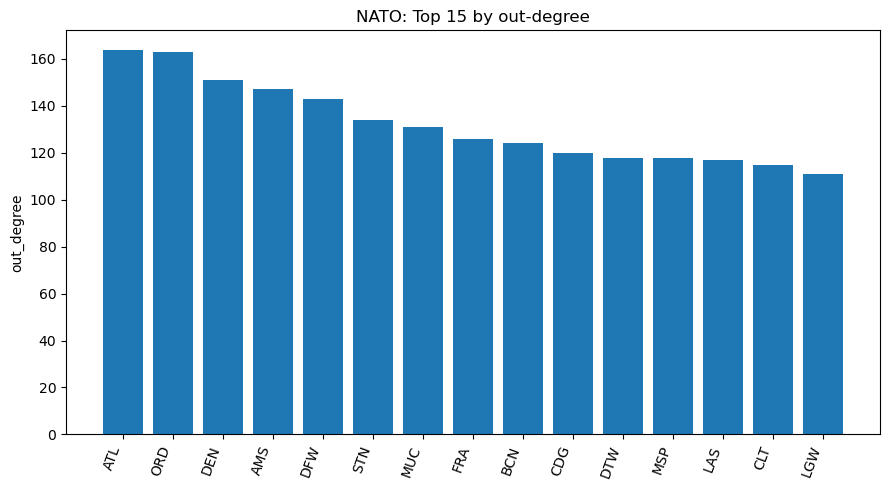

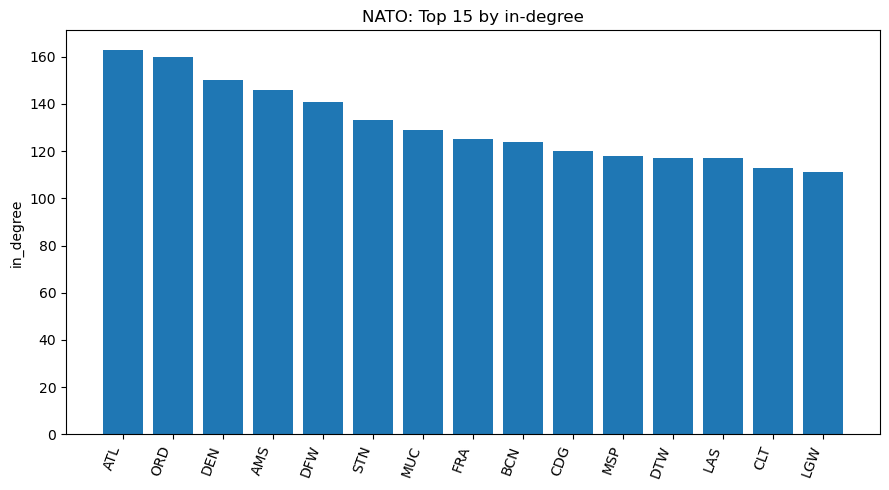

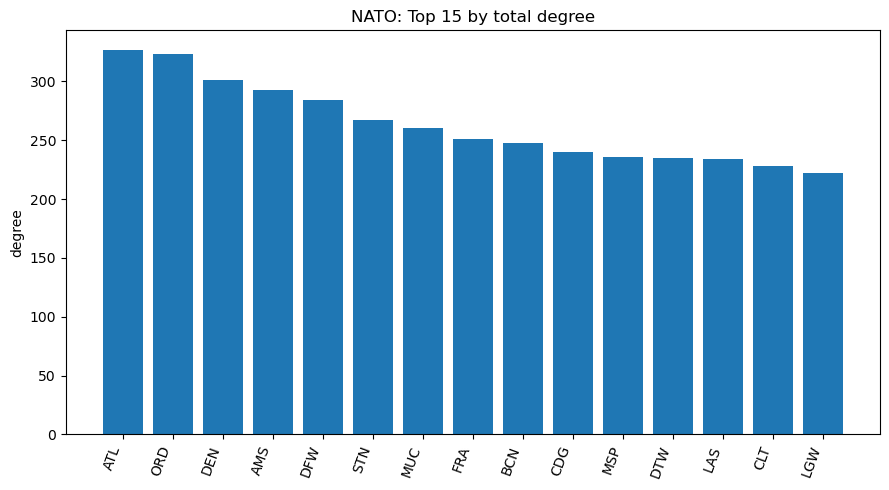

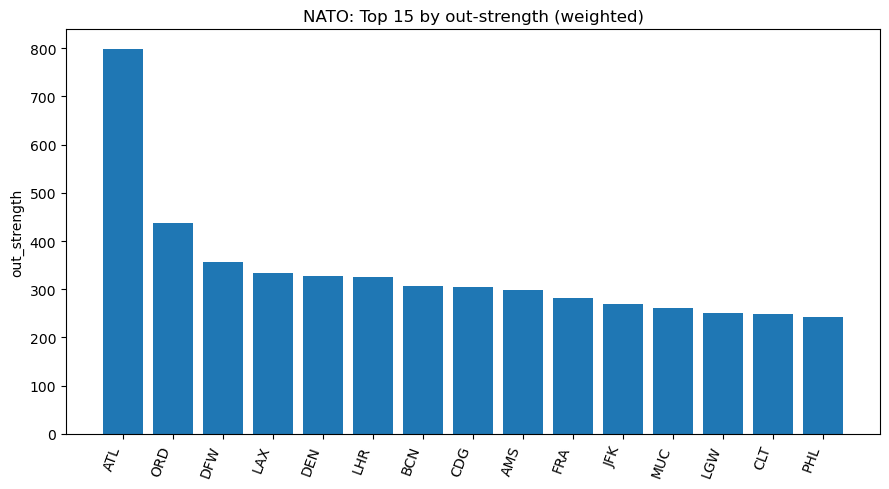

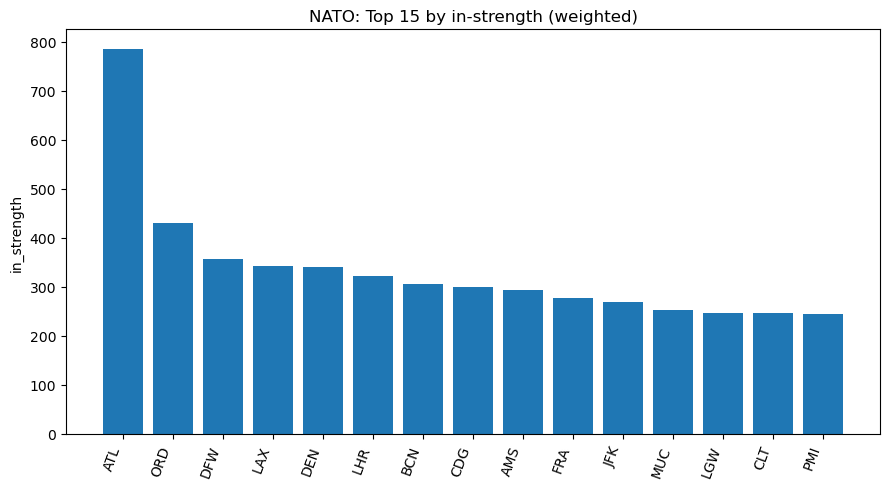

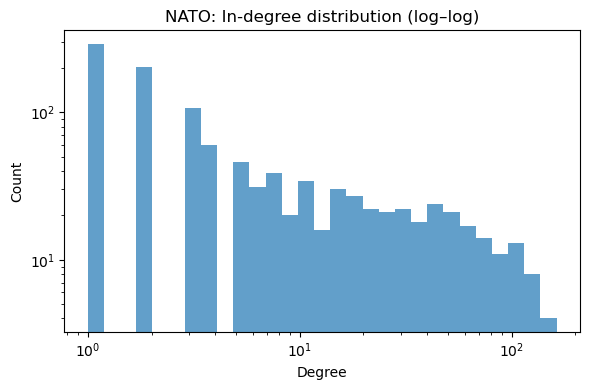

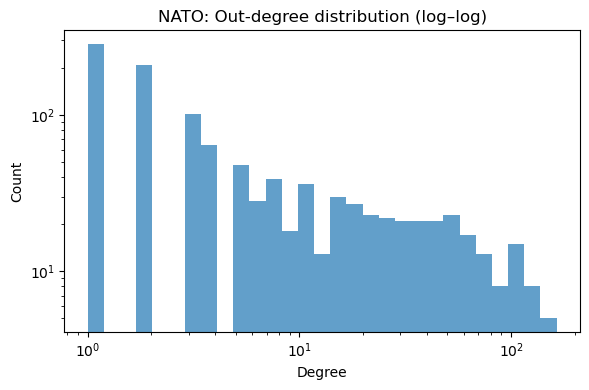

In [118]:
# -----------------------------
# 12) Plots
# -----------------------------
def plot_top_bar(df, value_col, title):
    if df.empty:
        print(f"[Plot skipped: {title} empty]")
        return
    plt.figure(figsize=(9,5))
    plt.bar(df["node"].astype(str), df[value_col].values)
    plt.xticks(rotation=70, ha="right")
    plt.ylabel(value_col); plt.title(title)
    plt.tight_layout(); plt.show()

plot_top_bar(top_out,  "out_degree",   "NATO: Top 15 by out-degree")
plot_top_bar(top_in,   "in_degree",    "NATO: Top 15 by in-degree")
plot_top_bar(top_deg,  "degree",       "NATO: Top 15 by total degree")
plot_top_bar(top_sout, "out_strength", "NATO: Top 15 by out-strength (weighted)")
plot_top_bar(top_sin,  "in_strength",  "NATO: Top 15 by in-strength (weighted)")

# Degree histograms (log-log, directed)
def plot_degree_hist(values, title):
    vals = np.fromiter(values.values(), dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        print(f"[Plot skipped: no positive values for {title}]"); return
    plt.figure(figsize=(6,4))
    bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 30)
    plt.hist(vals, bins=bins, alpha=0.7)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Degree"); plt.ylabel("Count"); plt.title(title)
    plt.tight_layout(); plt.show()

plot_degree_hist(in_deg,  "NATO: In-degree distribution (log–log)")
plot_degree_hist(out_deg, "NATO: Out-degree distribution (log–log)")
